In [1]:
!pip -q install lightgbm pyarrow

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    roc_auc_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 1. Paths and configuration


In [3]:
PROJECT_NAME = "alpha_ml"
BASE_DIR = Path("/content/drive/MyDrive") / PROJECT_NAME

FEATURES_DIR = BASE_DIR / "data" / "features"
MODELS_DIR = BASE_DIR / "models" / "02_cross_sectional"
RESULTS_DIR = BASE_DIR / "results"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
CHECKPOINT_ROOT = RESULTS_DIR / "02_checkpoints"
DATA_PATH = FEATURES_DIR / "model_dataset_full.parquet"
CONFIG_PATH = BASE_DIR / "config.json"

for directory in [MODELS_DIR, RESULTS_DIR, PREDICTIONS_DIR, CHECKPOINT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

TRAIN_END = pd.Timestamp("2021-12-31")
VALID_END = pd.Timestamp("2023-12-31")
LOOKBACK = 60
NN_DATES_PER_BATCH = 1
MAX_EPOCHS = 50
PATIENCE = 5
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 64
DROPOUT = 0.20
CROSS_SECTION_LAYERS = 1
LGBM_N_ESTIMATORS = 1000
LGBM_EARLY_STOPPING = 50
RESUME_COMPLETED_WINDOWS = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FAST_DEV_RUN = False
if FAST_DEV_RUN:
    RUN_WINDOWS = [int(config["return_windows"][0])]
    MODEL_NAMES_TO_RUN = None
    MAX_EPOCHS = 5
    PATIENCE = 2
    LGBM_N_ESTIMATORS = 30
    LGBM_EARLY_STOPPING = 5
    MAX_TRAIN_DATES = 30
    MAX_VALID_DATES = None
    MAX_TRAIN_VALID_DATES = 40
    MAX_TEST_DATES = 10
    OUTPUT_SUFFIX = "_dev"
else:
    RUN_WINDOWS = [int(w) for w in config["return_windows"]]
    MODEL_NAMES_TO_RUN = None
    MAX_TRAIN_DATES = None
    MAX_VALID_DATES = None
    MAX_TRAIN_VALID_DATES = None
    MAX_TEST_DATES = None
    OUTPUT_SUFFIX = ""


def seed_everything(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything()
print("Device:", DEVICE)
print("Windows:", RUN_WINDOWS)
print("FAST_DEV_RUN:", FAST_DEV_RUN)

Device: cuda
Windows: [1, 3, 5, 10, 20, 60]
FAST_DEV_RUN: False


## 2. Load notebook 01 output and create horizon-specific targets


In [4]:
df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

if df.duplicated(["date", "ticker"]).any():
    raise ValueError("Duplicate date-ticker rows found. Fix notebook 01 first.")

df["ticker_row_number"] = df.groupby("ticker").cumcount()

for window in RUN_WINDOWS:
    df[f"future_ret_{window}d"] = (
        df.groupby("ticker")[f"ret_{window}d"].shift(-window)
    )
    df[f"target_end_date_{window}d"] = (
        df.groupby("ticker")["date"].shift(-window)
    )

universe_df = df.loc[df["in_universe"]].copy()

for window in RUN_WINDOWS:
    future_col = f"future_ret_{window}d"
    end_column = f"target_end_date_{window}d"  # must be redefined for every window
    future_rank = universe_df.groupby("date")[future_col].rank(
        pct=True,
        method="average",
    )

    universe_df[f"bottom20_{window}d"] = (
        future_rank.lt(0.20).astype("Int8").where(future_rank.notna())
    )
    universe_df[f"middle60_{window}d"] = (
        future_rank.between(0.20, 0.80, inclusive="both")
        .astype("Int8")
        .where(future_rank.notna())
    )
    universe_df[f"top20_{window}d"] = (
        future_rank.gt(0.80).astype("Int8").where(future_rank.notna())
    )

    target = pd.Series(pd.NA, index=universe_df.index, dtype="Int8")
    target.loc[universe_df[f"bottom20_{window}d"].eq(1)] = 0
    target.loc[universe_df[f"middle60_{window}d"].eq(1)] = 1
    target.loc[universe_df[f"top20_{window}d"].eq(1)] = 2
    universe_df[f"target_class_{window}d"] = target

    universe_df[f"keep_train_{window}d"] = (
        universe_df["date"].le(TRAIN_END)
        & universe_df[end_column].le(TRAIN_END)
    )
    universe_df[f"keep_validation_{window}d"] = (
        universe_df["date"].gt(TRAIN_END)
        & universe_df["date"].le(VALID_END)
        & universe_df[end_column].le(VALID_END)
    )
    universe_df[f"keep_train_validation_{window}d"] = (
        universe_df["date"].le(VALID_END)
        & universe_df[end_column].le(VALID_END)
    )
    universe_df[f"keep_test_prediction_{window}d"] = (
        universe_df["date"].gt(VALID_END)
    )

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Rows:", f"{len(df):,}", "Universe rows:", f"{int(df['in_universe'].sum()):,}")

Date range: 2015-01-02 to 2025-12-30
Rows: 3,828,683 Universe rows: 1,257,000


## 3. Features and training-only robust scaling

Rank features remain in `[0, 1]`. Only `ret_*d`, `vol_*d`, and `close_to_ma_*d` are transformed:

$$x_{scaled}=\operatorname{clip}\left(\frac{x-\mathrm{training\ median}}{Q_{0.75}-Q_{0.25}},-5,5\right).$$


In [5]:
rank_feature_cols = (
    ["adj_close_rank", "volume_rank", "dollar_volume_rank", "dollar_volume_20d_rank"]
    + [f"ret_{w}d_rank" for w in config["return_windows"]]
    + [f"vol_{w}d_rank" for w in config["volatility_windows"]]
    + ["volume_20d_mean_rank", "volume_relative_20d_rank"]
)

continuous_feature_cols = (
    [f"ret_{w}d" for w in config["return_windows"]]
    + [f"vol_{w}d" for w in config["volatility_windows"]]
    + [f"close_to_ma_{w}d" for w in config["moving_average_windows"]]
)
feature_cols = rank_feature_cols + continuous_feature_cols

missing_features = sorted(set(feature_cols) - set(df.columns))
if missing_features:
    raise ValueError(f"Missing features: {missing_features}")

scale_fit_mask = df["date"].le(TRAIN_END) & df["in_universe"]
scale_fit = df.loc[scale_fit_mask, continuous_feature_cols].replace(
    [np.inf, -np.inf], np.nan
)
continuous_center = scale_fit.median()
continuous_scale = scale_fit.quantile(0.75) - scale_fit.quantile(0.25)
continuous_scale = continuous_scale.mask(continuous_scale.abs().lt(1e-8), 1.0)

df[continuous_feature_cols] = (
    df[continuous_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .sub(continuous_center)
    .div(continuous_scale)
    .clip(-5.0, 5.0)
)

# universe_df was copied before scaling, so update its model inputs from df.
universe_df.loc[:, continuous_feature_cols] = df.loc[
    universe_df.index, continuous_feature_cols
]

feature_fill_values = (
    df.loc[scale_fit_mask, feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .median()
)

# LightGBM uses only date t-1 inputs.
lagged_feature_cols = []
for col in feature_cols:
    lagged_col = f"{col}_lag1"
    universe_df[lagged_col] = (
        df.groupby("ticker", sort=False)[col].shift(1).loc[universe_df.index]
    )
    lagged_feature_cols.append(lagged_col)

print("Rank features:", len(rank_feature_cols))
print("Robust-scaled continuous features:", len(continuous_feature_cols))

Rank features: 14
Robust-scaled continuous features: 10


## 4. Split helpers and purge diagnostics


In [6]:
def limit_dates(rows, maximum_dates):
    rows = rows.sort_values(["date", "ticker"]).copy()
    if maximum_dates is not None:
        selected_dates = rows["date"].drop_duplicates().iloc[:maximum_dates]
        rows = rows.loc[rows["date"].isin(selected_dates)].copy()
    return rows


def get_model_rows(window, split):
    target_col = f"target_class_{window}d"
    keep = (
        universe_df[f"keep_{split}_{window}d"]
        & universe_df["ticker_row_number"].ge(LOOKBACK)
    )
    if split != "test_prediction":
        keep &= universe_df[target_col].notna()

    limits = {
        "train": MAX_TRAIN_DATES,
        "validation": MAX_VALID_DATES,
        "train_validation": MAX_TRAIN_VALID_DATES,
        "test_prediction": MAX_TEST_DATES,
    }
    return limit_dates(universe_df.loc[keep], limits[split])


split_diagnostic_rows = []
for window in RUN_WINDOWS:
    train_rows = get_model_rows(window, "train")
    valid_rows = get_model_rows(window, "validation")
    split_diagnostic_rows.append({
        "window": window,
        "train_rows": len(train_rows),
        "validation_rows": len(valid_rows),
        "validation_dates": valid_rows["date"].nunique(),
        "last_validation_signal_date": valid_rows["date"].max(),
        "last_validation_target_end": valid_rows[f"target_end_date_{window}d"].max(),
        "boundary_ok": valid_rows[f"target_end_date_{window}d"].max() <= VALID_END,
    })

split_diagnostics = pd.DataFrame(split_diagnostic_rows)
display(split_diagnostics)
if not split_diagnostics["boundary_ok"].all():
    raise ValueError("At least one horizon crosses the validation boundary.")


,window,train_rows,validation_rows,validation_dates,last_validation_signal_date,last_validation_target_end,boundary_ok
0,1,755500,250000,500,2023-12-28,2023-12-29,True
1,3,754500,249000,498,2023-12-26,2023-12-29,True
2,5,753500,248000,496,2023-12-21,2023-12-29,True
3,10,751000,245500,491,2023-12-14,2023-12-29,True
4,20,746000,240500,481,2023-11-30,2023-12-29,True
5,60,726000,220500,441,2023-10-04,2023-12-29,True


## 5. Pooled diagnostics and mean daily cross-sectional AUC


In [7]:
def daily_binary_auc(dates, binary_target, scores):
    work = pd.DataFrame({
        "date": pd.to_datetime(np.asarray(dates)),
        "positive": np.asarray(binary_target, dtype=np.int8),
        "score": np.asarray(scores, dtype=float),
    })
    work["score_rank"] = work.groupby("date")["score"].rank(method="average")
    grouped = work.groupby("date", sort=False)
    n = grouped.size().astype(float)
    n_positive = grouped["positive"].sum().astype(float)
    rank_sum_positive = (
        work["score_rank"].where(work["positive"].eq(1))
        .groupby(work["date"]).sum()
    )
    n_negative = n - n_positive
    auc = (
        rank_sum_positive - n_positive * (n_positive + 1.0) / 2.0
    ).div(n_positive * n_negative)
    return auc.loc[n_positive.gt(0.0) & n_negative.gt(0.0)]


def multiclass_metrics(y_true, probabilities, dates):
    y_true = np.asarray(y_true, dtype=np.int64)
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-7, 1.0 - 1e-7)
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)
    prediction = probabilities.argmax(axis=1)

    daily_auc = pd.concat(
        {
            "bottom": daily_binary_auc(dates, y_true == 0, probabilities[:, 0]),
            "middle": daily_binary_auc(dates, y_true == 1, probabilities[:, 1]),
            "top": daily_binary_auc(dates, y_true == 2, probabilities[:, 2]),
        },
        axis=1,
    ).dropna()
    daily_auc["macro"] = daily_auc[["bottom", "middle", "top"]].mean(axis=1)
    daily_auc["extreme"] = daily_auc[["bottom", "top"]].mean(axis=1)

    return {
        "n_observations": len(y_true),
        "n_dates": daily_auc.shape[0],
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "macro_f1": f1_score(y_true, prediction, average="macro"),
        "mean_daily_macro_auc": daily_auc["macro"].mean(),
        "mean_daily_extreme_auc": daily_auc["extreme"].mean(),
        "mean_daily_bottom_auc": daily_auc["bottom"].mean(),
        "mean_daily_middle_auc": daily_auc["middle"].mean(),
        "mean_daily_top_auc": daily_auc["top"].mean(),
        "pooled_macro_auc": roc_auc_score(
            y_true, probabilities, labels=[0, 1, 2], multi_class="ovr", average="macro"
        ),
        "log_loss": log_loss(y_true, probabilities, labels=[0, 1, 2]),
    }


def make_prediction_frame(samples, sample_indices, probabilities, window, model_name):
    target_col = f"target_class_{window}d"
    rows = (
        samples.reset_index(drop=True)
        .iloc[np.asarray(sample_indices, dtype=np.int64)][["date", "ticker", target_col]]
        .reset_index(drop=True)
        .rename(columns={target_col: "actual_class"})
    )
    rows["window"] = window
    rows["model"] = model_name
    rows[f"prob_bottom20_{window}d"] = probabilities[:, 0]
    rows[f"prob_middle60_{window}d"] = probabilities[:, 1]
    rows[f"prob_top20_{window}d"] = probabilities[:, 2]
    return rows


## 6. LightGBM baseline

LightGBM remains a row-level baseline. The neural networks below additionally receive the whole same-day universe through cross-sectional attention.


In [8]:
def make_lgbm(n_estimators, seed):
    return lgb.LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=n_estimators,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=100,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        verbosity=-1,
    )


def train_lgbm_validation(window):
    target_col = f"target_class_{window}d"
    train_rows = get_model_rows(window, "train")
    valid_rows = get_model_rows(window, "validation")
    model = make_lgbm(LGBM_N_ESTIMATORS, RANDOM_STATE + window)
    model.fit(
        train_rows[lagged_feature_cols],
        train_rows[target_col].astype(int),
        eval_set=[(valid_rows[lagged_feature_cols], valid_rows[target_col].astype(int))],
        eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(LGBM_EARLY_STOPPING, verbose=False)],
    )
    probabilities = model.predict_proba(valid_rows[lagged_feature_cols])
    metrics = multiclass_metrics(
        valid_rows[target_col].astype(int), probabilities, valid_rows["date"]
    )
    frame = make_prediction_frame(
        valid_rows, np.arange(len(valid_rows)), probabilities, window, "LightGBM"
    )
    row = {
        "window": window,
        "model": "LightGBM",
        "best_epoch": np.nan,
        "best_iteration": int(model.best_iteration_ or model.n_estimators),
        **metrics,
    }
    return model, frame, row

## 7. One date = one neural-network sample

With 500 stocks and `LOOKBACK=60`, one sample contains approximately `500 × 60` stock-day feature vectors. Batch size now counts dates, not individual stocks.


In [9]:
n_features = len(feature_cols)
ticker_list = sorted(df["ticker"].unique())
ticker_to_id = {ticker: i for i, ticker in enumerate(ticker_list)}
n_tickers = len(ticker_list)

features_by_ticker = {}
for ticker, ticker_df in df.groupby("ticker", sort=False):
    values = (
        ticker_df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(feature_fill_values)
        .to_numpy(dtype=np.float32)
    )
    if not np.isfinite(values).all():
        raise ValueError(f"Non-finite NN input remains for {ticker}.")
    features_by_ticker[ticker] = np.ascontiguousarray(values)


class DailyUniverseDataset(Dataset):
    def __init__(self, samples, window):
        self.samples = samples.reset_index(drop=True)
        self.target_col = f"target_class_{window}d"
        self.tickers = self.samples["ticker"].to_numpy()
        self.end_positions = self.samples["ticker_row_number"].to_numpy(dtype=np.int64)
        self.targets = self.samples[self.target_col].fillna(-100).to_numpy(dtype=np.int64)
        self.positions_by_date = [
            np.asarray(positions, dtype=np.int64)
            for positions in self.samples.groupby("date", sort=True).indices.values()
        ]

    def __len__(self):
        return len(self.positions_by_date)

    def __getitem__(self, index):
        positions = self.positions_by_date[index]
        tickers = self.tickers[positions]
        ends = self.end_positions[positions]
        sequences = np.stack([
            features_by_ticker[ticker][end - LOOKBACK:end]
            for ticker, end in zip(tickers, ends)
        ])
        ticker_ids = np.asarray([ticker_to_id[ticker] for ticker in tickers], dtype=np.int64)
        return (
            torch.from_numpy(sequences),
            torch.from_numpy(ticker_ids),
            torch.from_numpy(self.targets[positions]),
            torch.from_numpy(positions),
        )


def make_loader(samples, window, shuffle=False):
    dataset = DailyUniverseDataset(samples, window)
    return DataLoader(
        dataset,
        batch_size=NN_DATES_PER_BATCH,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=False,
    )

## 8. Temporal encoders followed by cross-sectional attention


In [10]:
class ContextualClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.ticker_embedding = nn.Embedding(n_tickers, HIDDEN_DIM)
        layer = nn.TransformerEncoderLayer(
            d_model=HIDDEN_DIM,
            nhead=4,
            dim_feedforward=HIDDEN_DIM * 2,
            dropout=DROPOUT,
            batch_first=True,
            activation="gelu",
        )
        self.cross_section = nn.TransformerEncoder(layer, num_layers=CROSS_SECTION_LAYERS)
        self.output = nn.Linear(HIDDEN_DIM, 3)

    def add_market_context(self, stock_embeddings, ticker_ids):
        contextual_input = stock_embeddings + self.ticker_embedding(ticker_ids)
        contextual = self.cross_section(contextual_input)
        return self.output(contextual)


class FCNNClassifier(ContextualClassifier):
    def __init__(self):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(LOOKBACK * n_features, HIDDEN_DIM * 2),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM),
            nn.ReLU(),
        )

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        encoded = self.temporal(x.reshape(batch * stocks, lookback, features))
        return self.add_market_context(encoded.reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class CNNClassifier(ContextualClassifier):
    def __init__(self):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv1d(n_features, HIDDEN_DIM, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(HIDDEN_DIM, HIDDEN_DIM, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        flat = x.reshape(batch * stocks, lookback, features).transpose(1, 2)
        encoded = self.temporal(flat).squeeze(-1)
        return self.add_market_context(encoded.reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class GRUClassifier(ContextualClassifier):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(n_features, HIDDEN_DIM, batch_first=True)

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        _, hidden = self.gru(x.reshape(batch * stocks, lookback, features))
        return self.add_market_context(hidden[-1].reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class TemporalTransformerMixin:
    def make_temporal_transformer(self, input_dim):
        self.temporal_projection = nn.Linear(input_dim, HIDDEN_DIM)
        self.temporal_position = nn.Parameter(torch.zeros(1, LOOKBACK, HIDDEN_DIM))
        layer = nn.TransformerEncoderLayer(
            d_model=HIDDEN_DIM,
            nhead=4,
            dim_feedforward=HIDDEN_DIM * 2,
            dropout=DROPOUT,
            batch_first=True,
            activation="gelu",
        )
        self.temporal_transformer = nn.TransformerEncoder(layer, num_layers=2)

    def temporal_transform(self, x):
        encoded = self.temporal_projection(x) + self.temporal_position[:, :x.shape[1]]
        return self.temporal_transformer(encoded).mean(dim=1)


class TransformerClassifier(TemporalTransformerMixin, ContextualClassifier):
    def __init__(self):
        ContextualClassifier.__init__(self)
        self.make_temporal_transformer(n_features)

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        encoded = self.temporal_transform(x.reshape(batch * stocks, lookback, features))
        return self.add_market_context(encoded.reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class CNNGRUClassifier(ContextualClassifier):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Conv1d(n_features, HIDDEN_DIM, kernel_size=3, padding=1)
        self.gru = nn.GRU(HIDDEN_DIM, HIDDEN_DIM, batch_first=True)

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        flat = x.reshape(batch * stocks, lookback, features)
        encoded = torch.relu(self.cnn(flat.transpose(1, 2))).transpose(1, 2)
        _, hidden = self.gru(encoded)
        return self.add_market_context(hidden[-1].reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


class CNNTransformerClassifier(TemporalTransformerMixin, ContextualClassifier):
    def __init__(self):
        ContextualClassifier.__init__(self)
        self.cnn = nn.Conv1d(n_features, HIDDEN_DIM, kernel_size=3, padding=1)
        self.make_temporal_transformer(HIDDEN_DIM)

    def forward(self, x, ticker_ids):
        batch, stocks, lookback, features = x.shape
        flat = x.reshape(batch * stocks, lookback, features)
        cnn_encoded = torch.relu(self.cnn(flat.transpose(1, 2))).transpose(1, 2)
        encoded = self.temporal_transform(cnn_encoded)
        return self.add_market_context(encoded.reshape(batch, stocks, HIDDEN_DIM), ticker_ids)


MODEL_CLASSES = {
    "FCNN": FCNNClassifier,
    "CNN": CNNClassifier,
    "GRU": GRUClassifier,
    "Transformer": TransformerClassifier,
    "CNN+GRU": CNNGRUClassifier,
    "CNN+Transformer": CNNTransformerClassifier,
}

if MODEL_NAMES_TO_RUN is None:
    MODEL_NAMES_TO_RUN = list(MODEL_CLASSES)

## 9. Neural-network training and prediction


In [11]:
@torch.no_grad()
def neural_predict(model, loader):
    model.eval()
    probability_parts = []
    position_parts = []
    for sequences, ticker_ids, _, positions in loader:
        sequences = sequences.to(DEVICE)
        ticker_ids = ticker_ids.to(DEVICE)
        logits = model(sequences, ticker_ids)
        probability_parts.append(torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy())
        position_parts.append(positions.squeeze(0).numpy())
    return np.concatenate(position_parts), np.concatenate(probability_parts)


def train_neural_validation(model_name, window):
    model_number = list(MODEL_CLASSES).index(model_name)
    seed_everything(RANDOM_STATE + 100 * window + model_number)
    target_col = f"target_class_{window}d"
    train_rows = get_model_rows(window, "train")
    valid_rows = get_model_rows(window, "validation")
    train_loader = make_loader(train_rows, window, shuffle=True)
    valid_loader = make_loader(valid_rows, window, shuffle=False)

    model = MODEL_CLASSES[model_name]().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    criterion = nn.CrossEntropyLoss(ignore_index=-100)
    best_auc = -np.inf
    best_state = None
    best_epoch = 0
    patience_left = PATIENCE
    history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        losses = []
        for sequences, ticker_ids, targets, _ in train_loader:
            sequences = sequences.to(DEVICE)
            ticker_ids = ticker_ids.to(DEVICE)
            targets = targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(sequences, ticker_ids)
            loss = criterion(logits.reshape(-1, 3), targets.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(float(loss.detach().cpu()))

        positions, probabilities = neural_predict(model, valid_loader)
        ordered = valid_rows.reset_index(drop=True).iloc[positions]
        metrics = multiclass_metrics(
            ordered[target_col].astype(int), probabilities, ordered["date"]
        )
        history.append({
            "window": window,
            "model": model_name,
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "validation_mean_daily_macro_auc": metrics["mean_daily_macro_auc"],
            "validation_mean_daily_extreme_auc": metrics["mean_daily_extreme_auc"],
            "validation_log_loss": metrics["log_loss"],
        })
        print(
            f"{window}d {model_name:15s} epoch={epoch:02d}",
            f"loss={np.mean(losses):.4f}",
            f"daily_auc={metrics['mean_daily_macro_auc']:.4f}",
            f"extreme_auc={metrics['mean_daily_extreme_auc']:.4f}",
        )

        if metrics["mean_daily_macro_auc"] > best_auc + 1e-5:
            best_auc = metrics["mean_daily_macro_auc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            patience_left = PATIENCE
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    model.load_state_dict(best_state)
    positions, probabilities = neural_predict(model, valid_loader)
    ordered = valid_rows.reset_index(drop=True).iloc[positions]
    final_metrics = multiclass_metrics(
        ordered[target_col].astype(int), probabilities, ordered["date"]
    )
    frame = make_prediction_frame(valid_rows, positions, probabilities, window, model_name)
    row = {
        "window": window,
        "model": model_name,
        "best_epoch": int(best_epoch),
        "best_iteration": np.nan,
        **final_metrics,
    }
    return model, frame, row, pd.DataFrame(history)


## 10. Train/select one window at a time, with resume checkpoints

Selection order is:

1. highest `mean_daily_macro_auc`;
2. highest `mean_daily_extreme_auc = (mean daily bottom AUC + mean daily top AUC) / 2`;
3. lowest log loss.

Completed windows are reused only when the run fingerprint matches the current data/model settings.


In [12]:
run_settings = {
    "pipeline_version": "cross_sectional_v1",
    "windows": RUN_WINDOWS,
    "lookback": LOOKBACK,
    "features": feature_cols,
    "train_end": str(TRAIN_END.date()),
    "valid_end": str(VALID_END.date()),
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "cross_section_layers": CROSS_SECTION_LAYERS,
    "seed": RANDOM_STATE,
    "fast_dev_run": FAST_DEV_RUN,
}
RUN_FINGERPRINT = hashlib.sha256(
    json.dumps(run_settings, sort_keys=True).encode()
).hexdigest()[:12]
CHECKPOINT_DIR = CHECKPOINT_ROOT / RUN_FINGERPRINT
MODEL_RUN_DIR = MODELS_DIR / RUN_FINGERPRINT
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Run fingerprint:", RUN_FINGERPRINT)


def select_best_row(metrics_frame):
    return (
        metrics_frame.sort_values(
            ["mean_daily_macro_auc", "mean_daily_extreme_auc", "log_loss"],
            ascending=[False, False, True],
        )
        .iloc[[0]]
        .reset_index(drop=True)
    )


validation_metric_frames = []
best_model_frames = []
training_history_frames = []
selected_validation_frames = []

for window in RUN_WINDOWS:
    metrics_path = CHECKPOINT_DIR / f"validation_metrics_{window}d.csv"
    best_path = CHECKPOINT_DIR / f"best_model_{window}d.csv"
    history_path = CHECKPOINT_DIR / f"training_history_{window}d.csv"
    predictions_path = CHECKPOINT_DIR / f"validation_selected_{window}d.parquet"

    checkpoint_files_exist = all(path.exists() for path in [
        metrics_path, best_path, history_path, predictions_path
    ])
    can_resume = False
    if checkpoint_files_exist:
        resume_best_row = pd.read_csv(best_path)
        if "validation_model_path" in resume_best_row.columns:
            can_resume = Path(
                resume_best_row.loc[0, "validation_model_path"]
            ).exists()
    if RESUME_COMPLETED_WINDOWS and can_resume:
        print(f"Loading completed validation window: {window}d")
        window_metrics = pd.read_csv(metrics_path)
        best_row = pd.read_csv(best_path)
        window_history = pd.read_csv(history_path)
        selected_frame = pd.read_parquet(predictions_path)
    else:
        print(f"\n===== Validation training for {window}d =====")
        metric_rows = []
        histories = []
        candidate_frames = {}
        candidate_nn_states = {}

        lgbm_model, lgbm_frame, lgbm_row = train_lgbm_validation(window)
        metric_rows.append(lgbm_row)
        candidate_frames["LightGBM"] = lgbm_frame

        for model_name in MODEL_NAMES_TO_RUN:
            model, frame, metric_row, history = train_neural_validation(model_name, window)
            metric_rows.append(metric_row)
            histories.append(history)
            candidate_frames[model_name] = frame
            candidate_nn_states[model_name] = {
                k: v.detach().cpu().clone() for k, v in model.state_dict().items()
            }
            del model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        window_metrics = pd.DataFrame(metric_rows)
        best_row = select_best_row(window_metrics)
        selected_model = best_row.loc[0, "model"]
        selected_frame = candidate_frames[selected_model]
        window_history = (
            pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
        )

        if selected_model == "LightGBM":
            validation_model_path = MODEL_RUN_DIR / f"validation_best_{window}d.joblib"
            joblib.dump(lgbm_model, validation_model_path)
        else:
            validation_model_path = MODEL_RUN_DIR / f"validation_best_{window}d.pt"
            torch.save({
                "run_fingerprint": RUN_FINGERPRINT,
                "window": window,
                "model_name": selected_model,
                "best_epoch": int(best_row.loc[0, "best_epoch"]),
                "state_dict": candidate_nn_states[selected_model],
                "feature_cols": feature_cols,
                "lookback": LOOKBACK,
                "ticker_to_id": ticker_to_id,
            }, validation_model_path)

        best_row["validation_model_path"] = str(validation_model_path)
        window_metrics.to_csv(metrics_path, index=False)
        best_row.to_csv(best_path, index=False)
        window_history.to_csv(history_path, index=False)
        selected_frame.to_parquet(predictions_path, index=False)
        print("Saved completed window:", window, "best model:", selected_model)

    validation_metric_frames.append(window_metrics)
    best_model_frames.append(best_row)
    training_history_frames.append(window_history)
    selected_validation_frames.append(selected_frame)

    # Update global recovery files after every completed window.
    pd.concat(validation_metric_frames, ignore_index=True).to_csv(
        RESULTS_DIR / f"02_validation_model_metrics{OUTPUT_SUFFIX}.csv", index=False
    )
    pd.concat(best_model_frames, ignore_index=True).to_csv(
        RESULTS_DIR / f"02_best_model_by_window{OUTPUT_SUFFIX}.csv", index=False
    )

validation_model_metrics = pd.concat(validation_metric_frames, ignore_index=True)
best_model_by_window = pd.concat(best_model_frames, ignore_index=True).sort_values("window")
training_history = pd.concat(training_history_frames, ignore_index=True)

print("Best model and best epoch by window:")
display(best_model_by_window)


Run fingerprint: 162266b43bbe

===== Validation training for 1d =====
1d FCNN            epoch=01 loss=0.9252 daily_auc=0.6145 extreme_auc=0.6030
1d FCNN            epoch=02 loss=0.9178 daily_auc=0.6196 extreme_auc=0.6077
1d FCNN            epoch=03 loss=0.9150 daily_auc=0.6239 extreme_auc=0.6116
1d FCNN            epoch=04 loss=0.9132 daily_auc=0.6246 extreme_auc=0.6122
1d FCNN            epoch=05 loss=0.9118 daily_auc=0.6248 extreme_auc=0.6123
1d FCNN            epoch=06 loss=0.9107 daily_auc=0.6261 extreme_auc=0.6135
1d FCNN            epoch=07 loss=0.9100 daily_auc=0.6271 extreme_auc=0.6144
1d FCNN            epoch=08 loss=0.9094 daily_auc=0.6251 extreme_auc=0.6125
1d FCNN            epoch=09 loss=0.9087 daily_auc=0.6267 extreme_auc=0.6137
1d FCNN            epoch=10 loss=0.9083 daily_auc=0.6258 extreme_auc=0.6130
1d FCNN            epoch=11 loss=0.9075 daily_auc=0.6260 extreme_auc=0.6131
1d FCNN            epoch=12 loss=0.9068 daily_auc=0.6248 extreme_auc=0.6118
1d CNN            

,window,model,best_epoch,best_iteration,n_observations,n_dates,accuracy,balanced_accuracy,macro_f1,mean_daily_macro_auc,mean_daily_extreme_auc,mean_daily_bottom_auc,mean_daily_middle_auc,mean_daily_top_auc,pooled_macro_auc,log_loss,validation_model_path
0,1,Transformer,11.0,NaN,250000,500,0.606480,0.361939,0.315518,0.630913,0.617607,0.621641,0.657526,0.613573,0.631022,0.909546,/content/drive/MyDrive/alpha_ml/models/02_cros...
1,3,CNN+Transformer,6.0,NaN,249000,498,0.605851,0.362601,0.321707,0.628571,0.615411,0.619546,0.654892,0.611275,0.628794,0.910170,/content/drive/MyDrive/alpha_ml/models/02_cros...
2,5,CNN+Transformer,5.0,NaN,248000,496,0.604379,0.365638,0.327843,0.626905,0.613556,0.617754,0.653605,0.609358,0.626951,0.913000,/content/drive/MyDrive/alpha_ml/models/02_cros...
3,10,Transformer,2.0,NaN,245500,491,0.601479,0.367790,0.327449,0.624053,0.611421,0.616600,0.649318,0.606243,0.623851,0.917253,/content/drive/MyDrive/alpha_ml/models/02_cros...
4,20,GRU,1.0,NaN,240500,481,0.598345,0.361305,0.316703,0.618754,0.605132,0.611897,0.645998,0.598368,0.618478,0.919767,/content/drive/MyDrive/alpha_ml/models/02_cros...
5,60,CNN+GRU,1.0,NaN,220500,441,0.600739,0.371543,0.339045,0.618053,0.597343,0.603990,0.659471,0.590696,0.618103,0.926340,/content/drive/MyDrive/alpha_ml/models/02_cros...


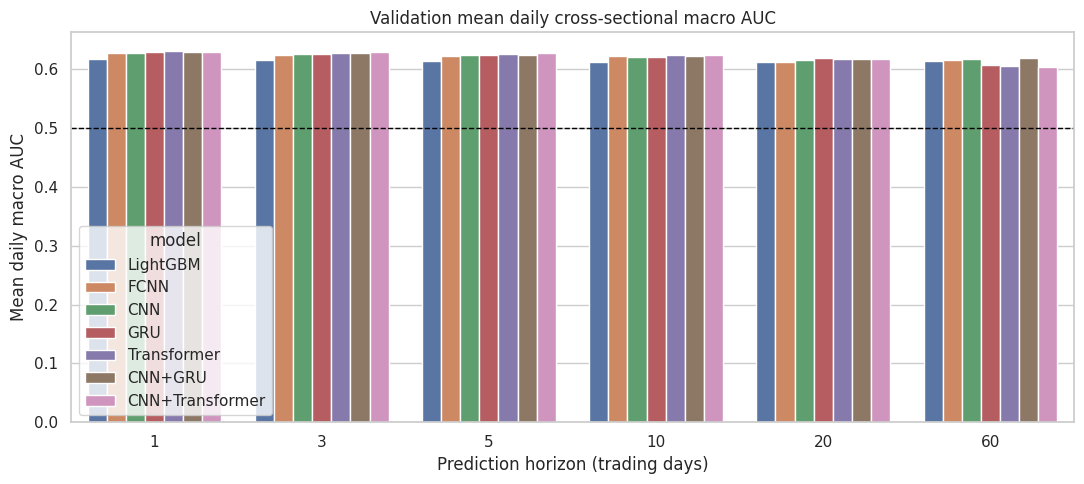

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=validation_model_metrics,
    x="window",
    y="mean_daily_macro_auc",
    hue="model",
    ax=ax,
)
ax.axhline(0.5, color="black", linewidth=1, linestyle="--")
ax.set_title("Validation mean daily cross-sectional macro AUC")
ax.set_xlabel("Prediction horizon (trading days)")
ax.set_ylabel("Mean daily macro AUC")
plt.tight_layout()
plt.show()


## 11. Refit selected systems on train + validation and predict test


In [14]:
def train_neural_fixed_epochs(model_name, window, epochs, fit_rows):
    model_number = list(MODEL_CLASSES).index(model_name)
    seed_everything(RANDOM_STATE + 10_000 + 100 * window + model_number)
    loader = make_loader(fit_rows, window, shuffle=True)
    model = MODEL_CLASSES[model_name]().to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    criterion = nn.CrossEntropyLoss(ignore_index=-100)

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for sequences, ticker_ids, targets, _ in loader:
            sequences = sequences.to(DEVICE)
            ticker_ids = ticker_ids.to(DEVICE)
            targets = targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(sequences, ticker_ids)
            loss = criterion(logits.reshape(-1, 3), targets.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            losses.append(float(loss.detach().cpu()))
        print(f"Final {window}d {model_name} epoch={epoch:02d} loss={np.mean(losses):.4f}")
    return model


selected_test_frames = []
saved_model_paths = {}

for selection in best_model_by_window.itertuples(index=False):
    window = int(selection.window)
    model_name = selection.model
    target_col = f"target_class_{window}d"
    safe_name = model_name.replace("+", "_plus_").lower()
    test_part_path = CHECKPOINT_DIR / f"test_selected_{window}d.parquet"
    final_model_path = MODEL_RUN_DIR / (
        f"final_{safe_name}_{window}d.joblib" if model_name == "LightGBM"
        else f"final_{safe_name}_{window}d.pt"
    )

    if RESUME_COMPLETED_WINDOWS and test_part_path.exists() and final_model_path.exists():
        print(f"Loading completed refit/test window: {window}d")
        selected_test_frames.append(pd.read_parquet(test_part_path))
        saved_model_paths[window] = str(final_model_path)
        continue

    fit_rows = get_model_rows(window, "train_validation")
    test_rows = get_model_rows(window, "test_prediction")

    if model_name == "LightGBM":
        tree_count = int(selection.best_iteration)
        final_model = make_lgbm(tree_count, RANDOM_STATE + 10_000 + window)
        final_model.fit(
            fit_rows[lagged_feature_cols], fit_rows[target_col].astype(int)
        )
        probabilities = final_model.predict_proba(test_rows[lagged_feature_cols])
        positions = np.arange(len(test_rows))
        joblib.dump(final_model, final_model_path)
    else:
        epochs = int(selection.best_epoch)
        final_model = train_neural_fixed_epochs(model_name, window, epochs, fit_rows)
        positions, probabilities = neural_predict(
            final_model, make_loader(test_rows, window, shuffle=False)
        )
        torch.save({
            "run_fingerprint": RUN_FINGERPRINT,
            "window": window,
            "model_name": model_name,
            "best_epoch": epochs,
            "state_dict": {k: v.detach().cpu() for k, v in final_model.state_dict().items()},
            "feature_cols": feature_cols,
            "lookback": LOOKBACK,
            "ticker_to_id": ticker_to_id,
        }, final_model_path)

    frame = make_prediction_frame(
        test_rows, positions, probabilities, window, model_name
    )
    frame.to_parquet(test_part_path, index=False)
    selected_test_frames.append(frame)
    saved_model_paths[window] = str(final_model_path)
    del final_model, fit_rows, test_rows, probabilities
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Saved refit/test window:", window)


Final 1d Transformer epoch=01 loss=0.9236
Final 1d Transformer epoch=02 loss=0.9141
Final 1d Transformer epoch=03 loss=0.9114
Final 1d Transformer epoch=04 loss=0.9103
Final 1d Transformer epoch=05 loss=0.9095
Final 1d Transformer epoch=06 loss=0.9089
Final 1d Transformer epoch=07 loss=0.9085
Final 1d Transformer epoch=08 loss=0.9080
Final 1d Transformer epoch=09 loss=0.9077
Final 1d Transformer epoch=10 loss=0.9073
Final 1d Transformer epoch=11 loss=0.9071
Saved refit/test window: 1
Final 3d CNN+Transformer epoch=01 loss=0.9221
Final 3d CNN+Transformer epoch=02 loss=0.9132
Final 3d CNN+Transformer epoch=03 loss=0.9102
Final 3d CNN+Transformer epoch=04 loss=0.9086
Final 3d CNN+Transformer epoch=05 loss=0.9075
Final 3d CNN+Transformer epoch=06 loss=0.9066
Saved refit/test window: 3
Final 5d CNN+Transformer epoch=01 loss=0.9208
Final 5d CNN+Transformer epoch=02 loss=0.9124
Final 5d CNN+Transformer epoch=03 loss=0.9096
Final 5d CNN+Transformer epoch=04 loss=0.9077
Final 5d CNN+Transformer

## 12. Test diagnostics and consolidated outputs


In [15]:
def merge_window_predictions(frames):
    merged = None
    for frame in frames:
        window = int(frame["window"].iloc[0])
        current = frame.drop(columns=["window"]).rename(columns={
            "model": f"selected_model_{window}d",
            "actual_class": f"actual_class_{window}d",
        })
        merged = current if merged is None else merged.merge(
            current, on=["date", "ticker"], how="outer"
        )
    return merged.sort_values(["date", "ticker"]).reset_index(drop=True)


test_metric_rows = []
for frame in selected_test_frames:
    window = int(frame["window"].iloc[0])
    observed = frame["actual_class"].notna()
    probability_cols = [
        f"prob_bottom20_{window}d",
        f"prob_middle60_{window}d",
        f"prob_top20_{window}d",
    ]
    if observed.any():
        metrics = multiclass_metrics(
            frame.loc[observed, "actual_class"].astype(int),
            frame.loc[observed, probability_cols],
            frame.loc[observed, "date"],
        )
        test_metric_rows.append({
            "window": window,
            "selected_model": frame["model"].iloc[0],
            **metrics,
        })

test_selected_metrics = pd.DataFrame(test_metric_rows)
validation_selected_predictions = merge_window_predictions(selected_validation_frames)
test_selected_predictions = merge_window_predictions(selected_test_frames)
display(test_selected_metrics)
display(test_selected_predictions.head())


,window,selected_model,n_observations,n_dates,accuracy,balanced_accuracy,macro_f1,mean_daily_macro_auc,mean_daily_extreme_auc,mean_daily_bottom_auc,mean_daily_middle_auc,mean_daily_top_auc,pooled_macro_auc,log_loss
0,1,Transformer,250000,500,0.605804,0.359087,0.310431,0.633929,0.620613,0.621747,0.660562,0.619479,0.634076,0.908491
1,3,CNN+Transformer,249000,498,0.606032,0.359392,0.314603,0.632568,0.618917,0.616474,0.659871,0.621360,0.632605,0.909225
2,5,CNN+Transformer,248000,496,0.605456,0.352435,0.298082,0.633826,0.620038,0.617046,0.661401,0.623031,0.633913,0.908820
3,10,Transformer,245500,491,0.605234,0.353149,0.299354,0.632154,0.619135,0.615902,0.658192,0.622369,0.631915,0.909853
4,20,GRU,240500,481,0.603904,0.352173,0.299189,0.630470,0.616344,0.611301,0.658722,0.621388,0.630571,0.911310
5,60,CNN+GRU,220499,441,0.600796,0.360582,0.321640,0.625489,0.607614,0.612532,0.661239,0.602697,0.626325,0.917571


,date,ticker,actual_class_1d,selected_model_1d,prob_bottom20_1d,prob_middle60_1d,prob_top20_1d,actual_class_3d,selected_model_3d,prob_bottom20_3d,prob_middle60_3d,prob_top20_3d,actual_class_5d,selected_model_5d,prob_bottom20_5d,prob_middle60_5d,prob_top20_5d,actual_class_10d,selected_model_10d,prob_bottom20_10d,prob_middle60_10d,prob_top20_10d,actual_class_20d,selected_model_20d,prob_bottom20_20d,prob_middle60_20d,prob_top20_20d,actual_class_60d,selected_model_60d,prob_bottom20_60d,prob_middle60_60d,prob_top20_60d
0,2024-01-02,A,0,Transformer,0.114718,0.746096,0.139186,0,CNN+Transformer,0.107459,0.791009,0.101532,0,CNN+Transformer,0.107898,0.768391,0.123711,0,Transformer,0.126421,0.770684,0.102895,0,GRU,0.143535,0.702890,0.153575,1,CNN+GRU,0.153350,0.626263,0.220387
1,2024-01-02,AA,0,Transformer,0.351769,0.335843,0.312388,0,CNN+Transformer,0.340143,0.325144,0.334713,0,CNN+Transformer,0.330843,0.372888,0.296269,0,Transformer,0.360133,0.334828,0.305038,0,GRU,0.367393,0.371870,0.260737,1,CNN+GRU,0.435802,0.282985,0.281213
2,2024-01-02,AAL,0,Transformer,0.273212,0.463531,0.263257,2,CNN+Transformer,0.326119,0.398747,0.275134,2,CNN+Transformer,0.302401,0.400505,0.297094,1,Transformer,0.331666,0.395428,0.272905,2,GRU,0.293901,0.471404,0.234695,1,CNN+GRU,0.304766,0.476752,0.218481
3,2024-01-02,AAP,1,Transformer,0.365597,0.326746,0.307657,1,CNN+Transformer,0.329245,0.390072,0.280683,1,CNN+Transformer,0.316033,0.382923,0.301044,1,Transformer,0.355441,0.372290,0.272269,2,GRU,0.297409,0.418595,0.283996,2,CNN+GRU,0.350634,0.426056,0.223310
4,2024-01-02,AAPL,1,Transformer,0.128835,0.712659,0.158507,1,CNN+Transformer,0.159129,0.656011,0.184860,1,CNN+Transformer,0.126666,0.699334,0.174000,1,Transformer,0.139134,0.668501,0.192365,1,GRU,0.165168,0.634895,0.199937,0,CNN+GRU,0.080436,0.684566,0.234998


In [16]:
validation_metrics_path = RESULTS_DIR / f"02_validation_model_metrics{OUTPUT_SUFFIX}.csv"
best_models_path = RESULTS_DIR / f"02_best_model_by_window{OUTPUT_SUFFIX}.csv"
history_path = RESULTS_DIR / f"02_neural_training_history{OUTPUT_SUFFIX}.csv"
test_metrics_path = RESULTS_DIR / f"02_test_selected_metrics{OUTPUT_SUFFIX}.csv"
validation_predictions_path = PREDICTIONS_DIR / (
    f"02_validation_selected_probabilities{OUTPUT_SUFFIX}.parquet"
)
test_predictions_path = PREDICTIONS_DIR / (
    f"02_test_selected_probabilities{OUTPUT_SUFFIX}.parquet"
)
preprocessing_path = MODEL_RUN_DIR / f"preprocessing{OUTPUT_SUFFIX}.joblib"
metadata_path = RESULTS_DIR / f"02_multiclass_metadata{OUTPUT_SUFFIX}.json"

validation_model_metrics.to_csv(validation_metrics_path, index=False)
best_model_by_window.to_csv(best_models_path, index=False)
training_history.to_csv(history_path, index=False)
test_selected_metrics.to_csv(test_metrics_path, index=False)
validation_selected_predictions.to_parquet(validation_predictions_path, index=False)
test_selected_predictions.to_parquet(test_predictions_path, index=False)

joblib.dump({
    "run_fingerprint": RUN_FINGERPRINT,
    "feature_cols": feature_cols,
    "rank_feature_cols": rank_feature_cols,
    "continuous_feature_cols": continuous_feature_cols,
    "continuous_center": continuous_center,
    "continuous_scale": continuous_scale,
    "feature_fill_values": feature_fill_values,
    "lagged_feature_cols": lagged_feature_cols,
    "ticker_to_id": ticker_to_id,
    "lookback": LOOKBACK,
}, preprocessing_path)

metadata = {
    **run_settings,
    "run_fingerprint": RUN_FINGERPRINT,
    "classes": {"0": "bottom20", "1": "middle60", "2": "top20"},
    "feature_timing": "prediction date t uses histories ending at t-1",
    "nn_sample": "one complete date: stocks x lookback x features",
    "cross_stock_context": "ticker embedding plus cross-sectional self-attention",
    "selection_rule": (
        "highest mean_daily_macro_auc; highest mean_daily_extreme_auc tie-break; "
        "lowest log_loss second tie-break"
    ),
    "saved_model_paths": {str(k): v for k, v in saved_model_paths.items()},
}
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
for path in [
    validation_metrics_path,
    best_models_path,
    history_path,
    test_metrics_path,
    validation_predictions_path,
    test_predictions_path,
    preprocessing_path,
    metadata_path,
    *[Path(path) for path in saved_model_paths.values()],
]:
    print(" -", path)


Saved:
 - /content/drive/MyDrive/alpha_ml/results/02_validation_model_metrics.csv
 - /content/drive/MyDrive/alpha_ml/results/02_best_model_by_window.csv
 - /content/drive/MyDrive/alpha_ml/results/02_neural_training_history.csv
 - /content/drive/MyDrive/alpha_ml/results/02_test_selected_metrics.csv
 - /content/drive/MyDrive/alpha_ml/results/predictions/02_validation_selected_probabilities.parquet
 - /content/drive/MyDrive/alpha_ml/results/predictions/02_test_selected_probabilities.parquet
 - /content/drive/MyDrive/alpha_ml/models/02_cross_sectional/162266b43bbe/preprocessing.joblib
 - /content/drive/MyDrive/alpha_ml/results/02_multiclass_metadata.json
 - /content/drive/MyDrive/alpha_ml/models/02_cross_sectional/162266b43bbe/final_transformer_1d.pt
 - /content/drive/MyDrive/alpha_ml/models/02_cross_sectional/162266b43bbe/final_cnn_plus_transformer_3d.pt
 - /content/drive/MyDrive/alpha_ml/models/02_cross_sectional/162266b43bbe/final_cnn_plus_transformer_5d.pt
 - /content/drive/MyDrive/alp

## Reading the results

- `mean_daily_macro_auc` measures within-day stock ranking and is the primary validation selection metric.
- `mean_daily_extreme_auc` is the average of bottom and top daily AUC and breaks macro-AUC ties.
- `pooled_macro_auc` is retained only as a diagnostic.
- A completed horizon is stored under `results/02_checkpoints/<run fingerprint>/`; rerunning the notebook with identical settings skips it.
- Test metrics are diagnostic only. Portfolio rules and horizon allocations must not be changed after inspecting test.
